In [1]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [2]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.9/112.6 GB disk)


In [3]:
from ultralytics import YOLO

from IPython.display import display, Image

In [4]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow==1.1.48 --quiet

import roboflow
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="aRKEixHGcPDoAPDNMOb5")
project = rf.workspace("bulonvit").project("nhandien_ocvit")
version = project.version(9)
dataset = version.download("yolov8")


/content/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Nhandien_ocvit-9 in yolov8:: 100%|██████████| 58/58 [00:00<00:00, 7197.54it/s]


## Custom Training

In [5]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

/content
100% 21.5M/21.5M [00:00<00:00, 93.8MB/s]
New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/datasets/Nhandien_ocvit-9/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fa

/content


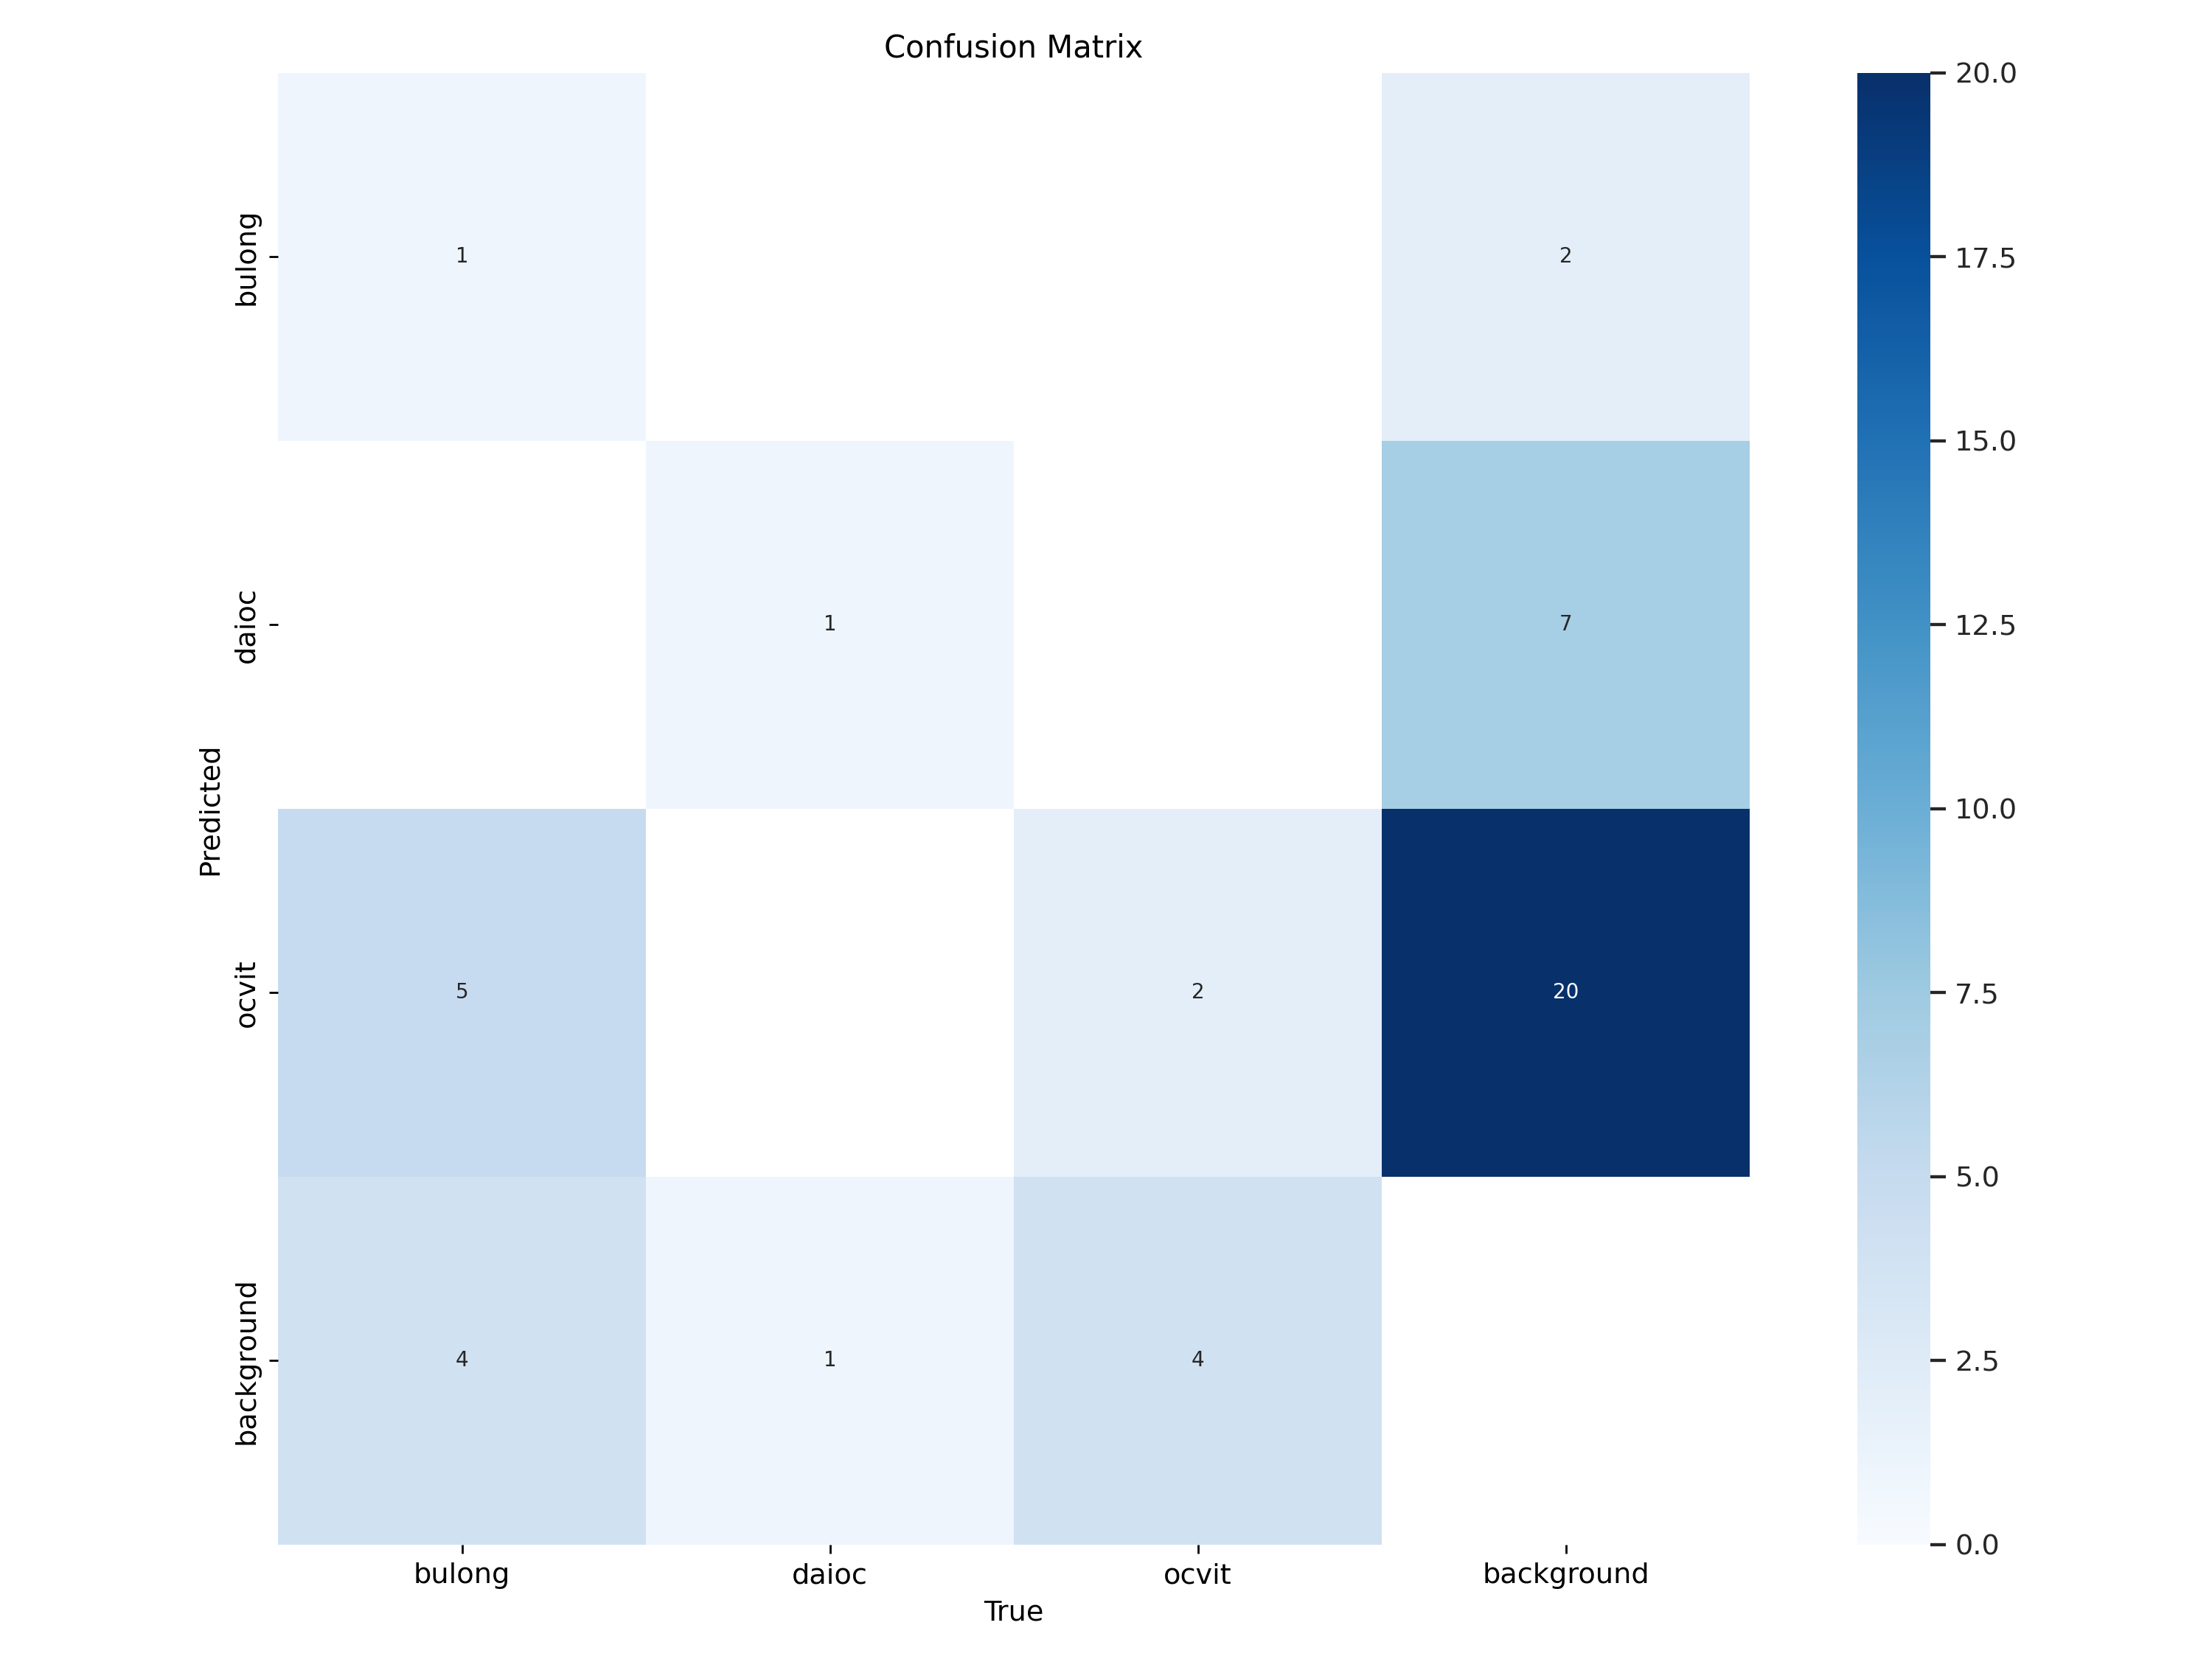

In [6]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


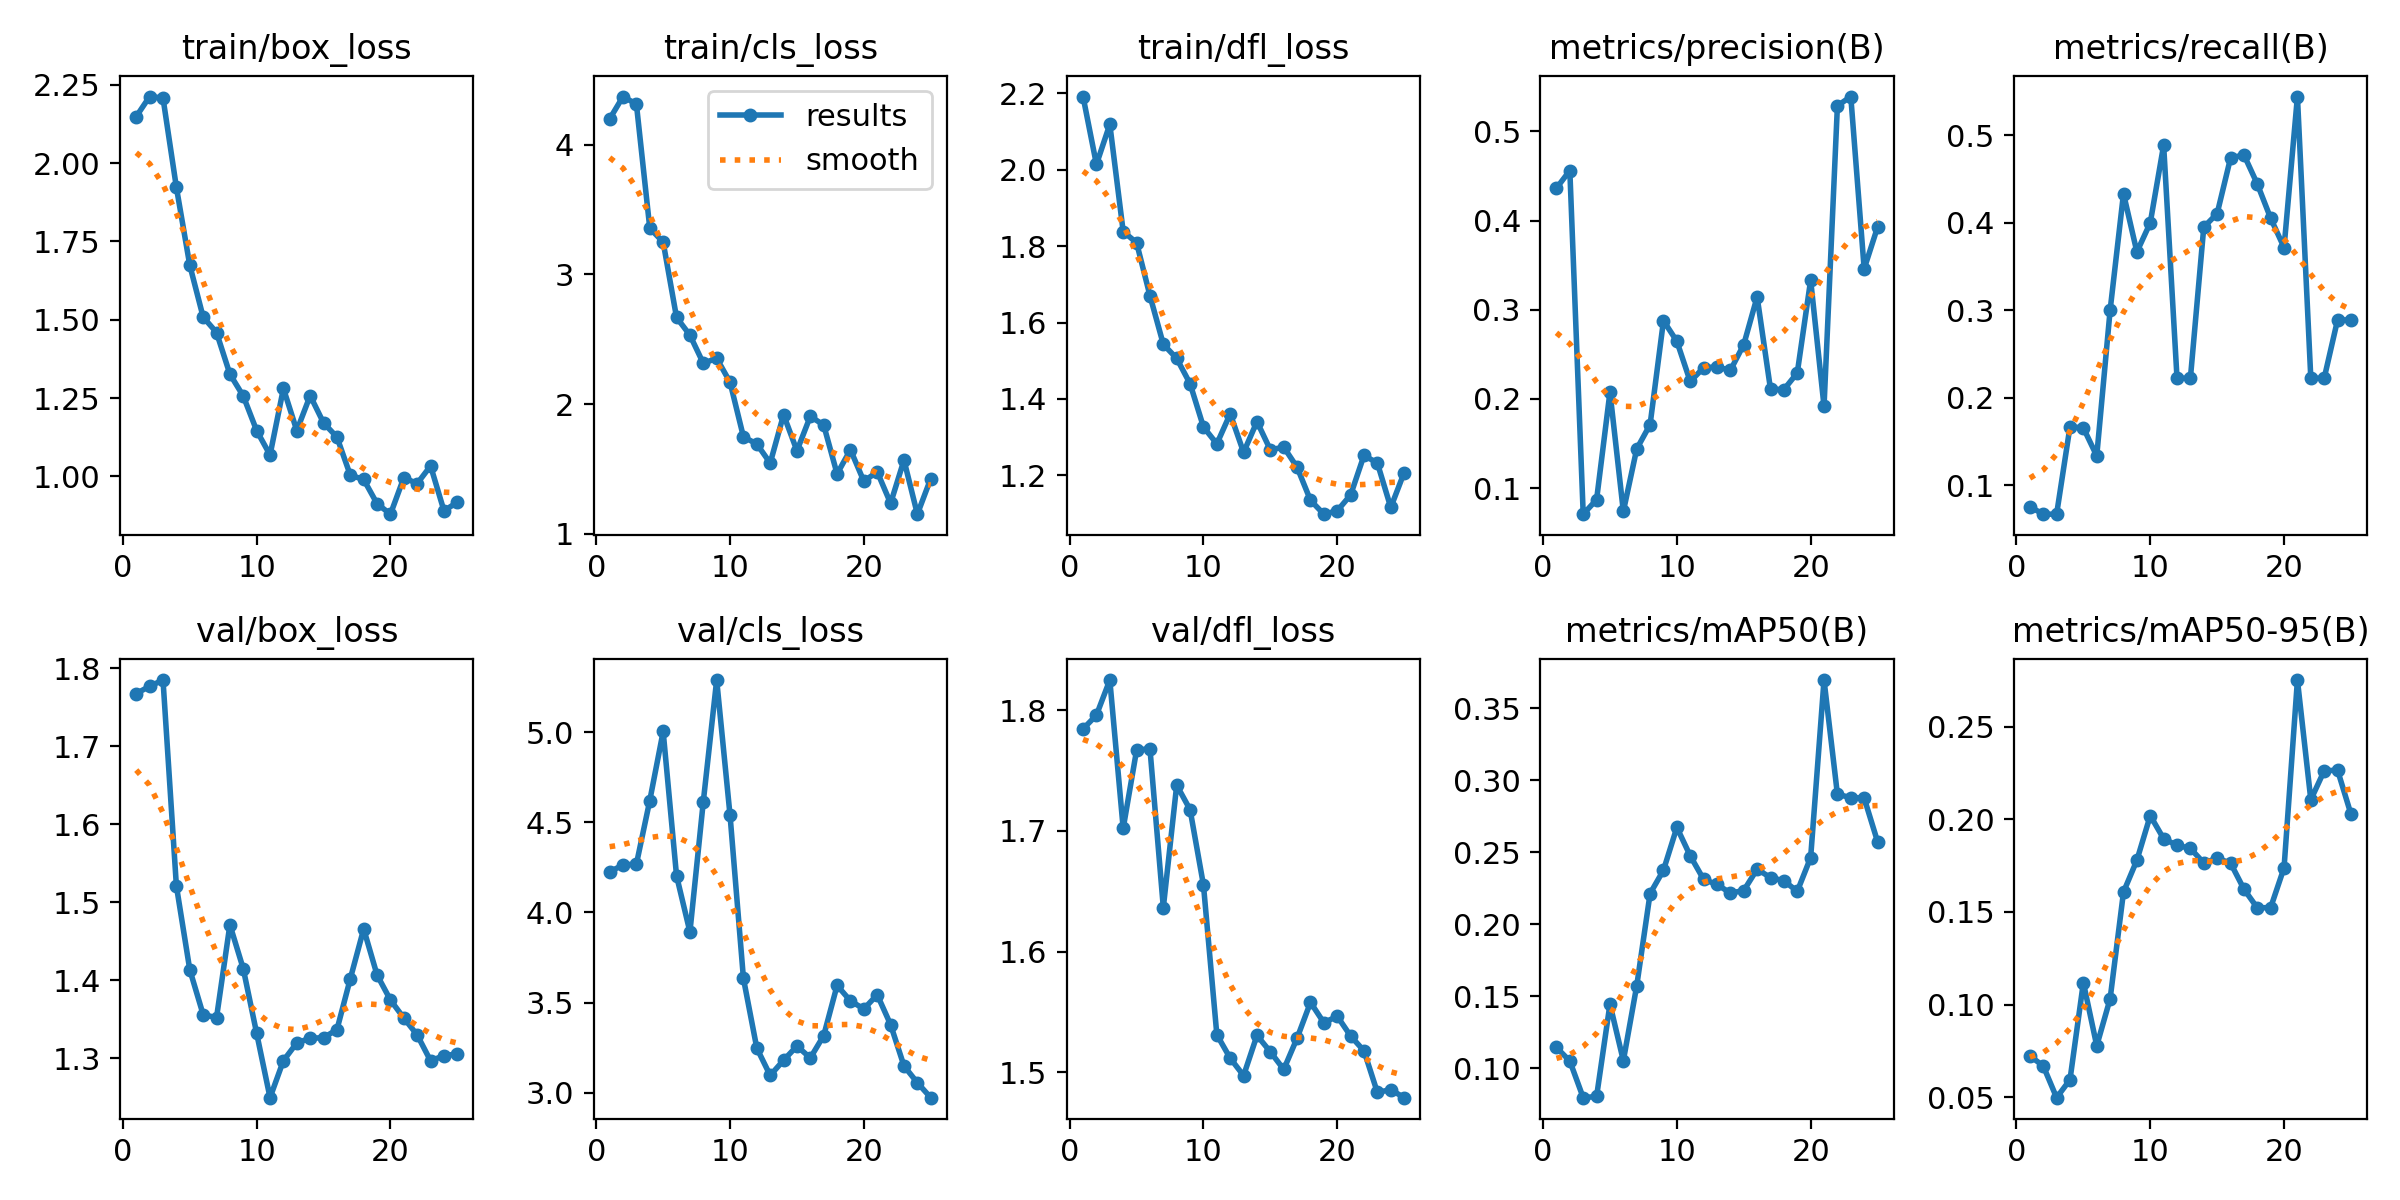

In [7]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


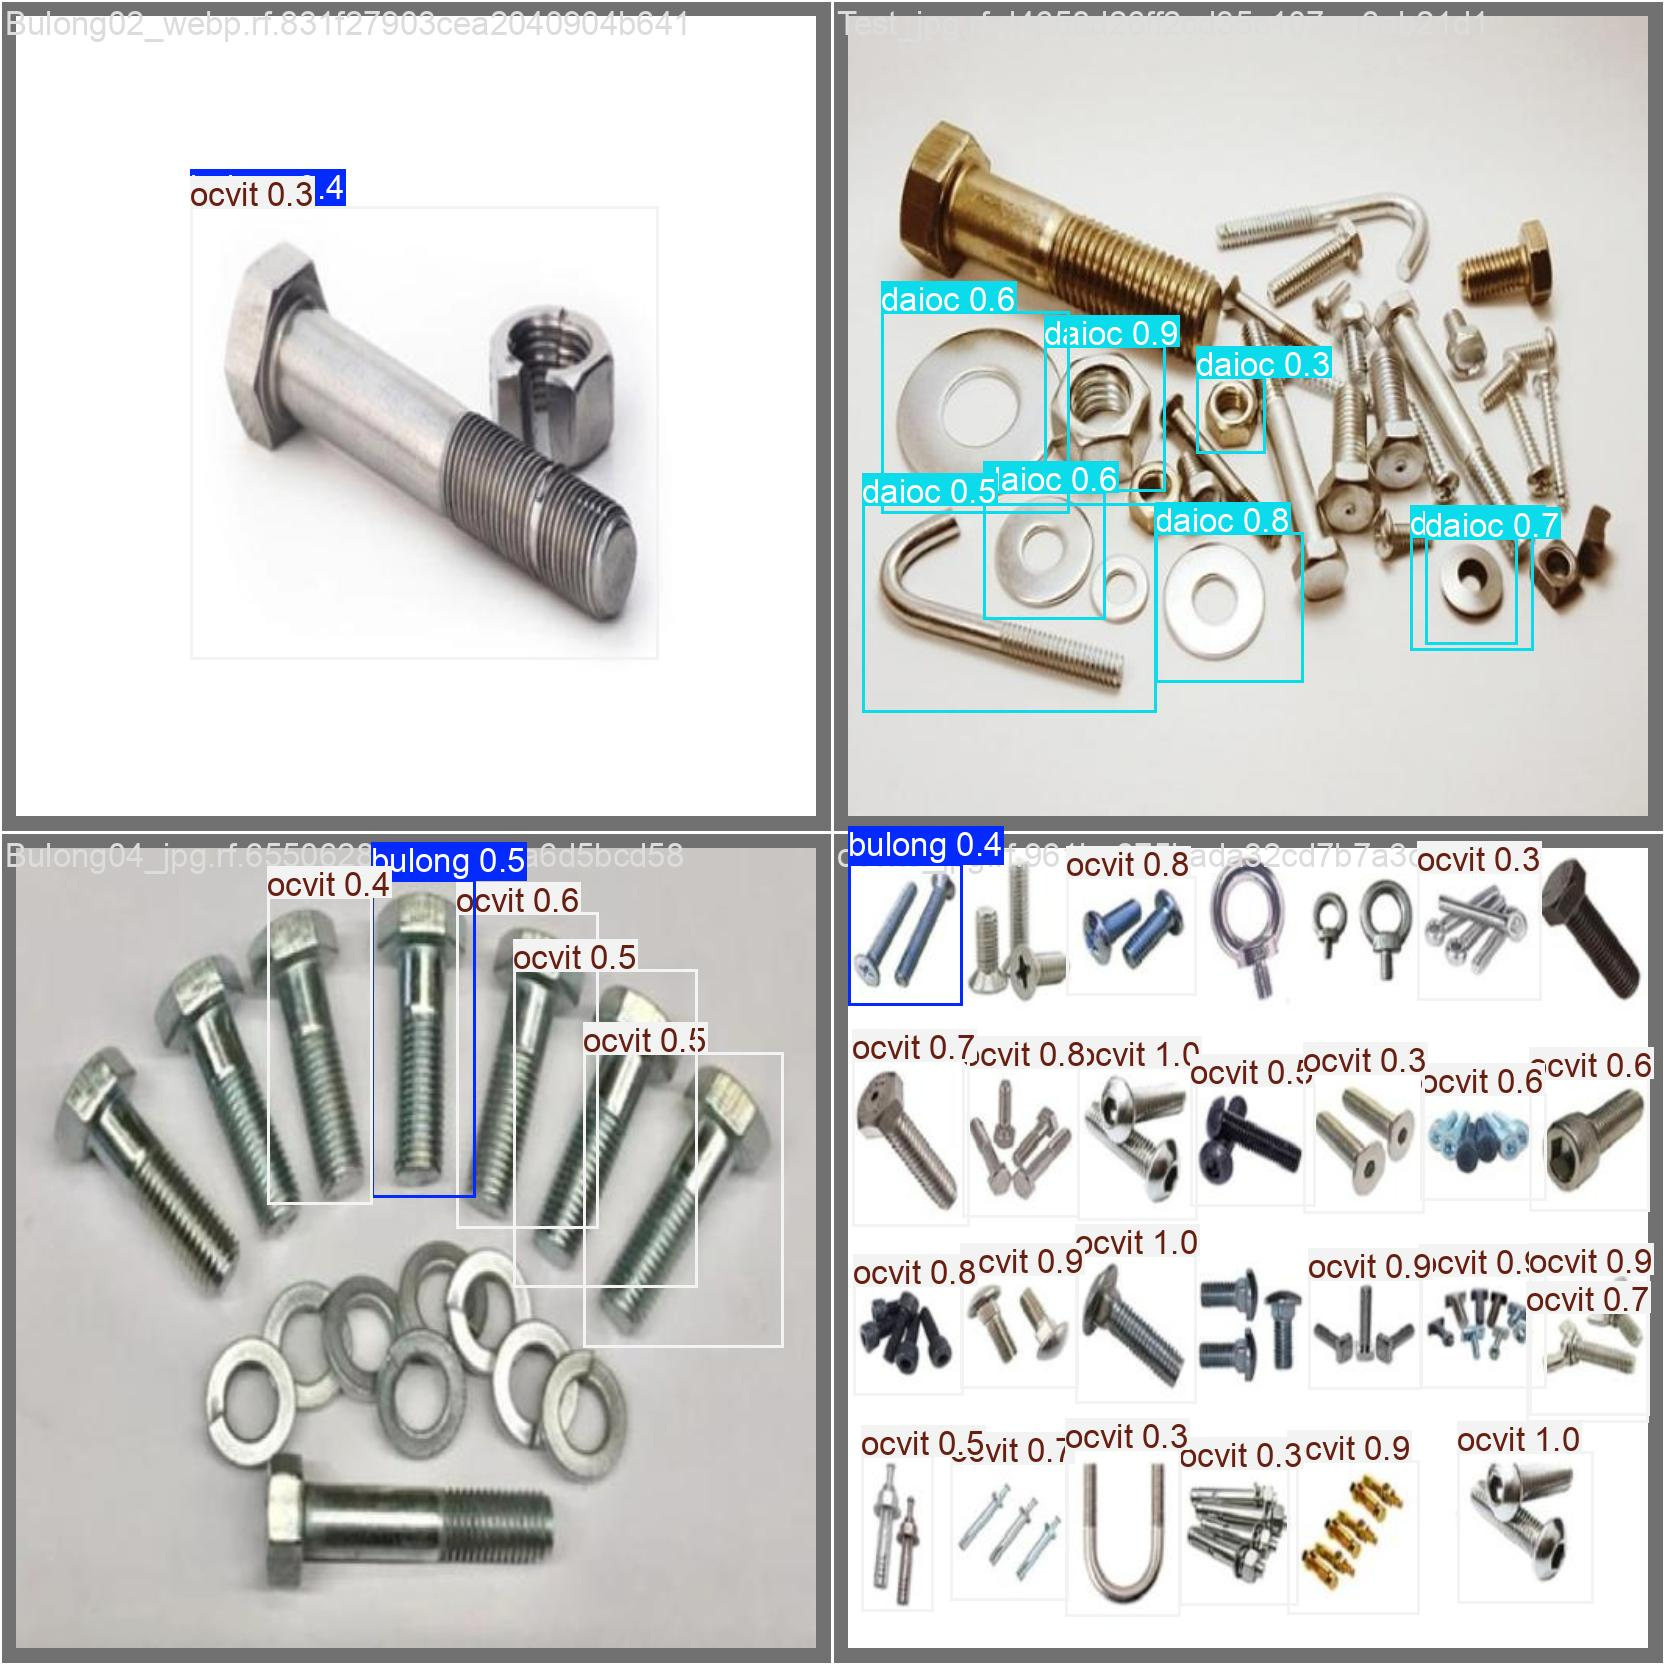

In [8]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [9]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/datasets/Nhandien_ocvit-9/valid/labels.cache... 4 images, 0 backgrounds, 0 corrupt: 100% 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:00<00:00,  3.47it/s]
                   all          4         18      0.192      0.544      0.369      0.274
                bulong          4         10      0.398        0.3      0.482      0.341
                 daioc          2          2      0.124          1      0.578      0.454
                 ocvit          2          6      0.056      0.333     0.0467     0.0257
Speed: 0.4ms preprocess, 22.9ms inference, 0.0ms loss, 23.8ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with Custom Model

In [10]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

image 1/1 /content/datasets/Nhandien_ocvit-9/test/images/TESTBEST_jpg.rf.096629edd6f86918e69395eab16627d6.jpg: 800x800 4 bulongs, 6 daiocs, 3 ocvits, 22.2ms
Speed: 5.4ms preprocess, 22.2ms inference, 74.8ms postprocess per image at shape (1, 3, 800, 800)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
!cp -r /content/* /content/drive/MyDrive/CS417/

cp: cannot stat '/content/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encrypted/MyDrive/CS417/drive/.Encryp